<a href="https://colab.research.google.com/github/RafaelaMlucca/AnaliseViolMulher/blob/main/06_modelagem_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 06 — Modelagem

**Projeto:** Assinaturas preditivas dos tipos de violência contra a mulher  
**Autora:** Rafaela Lucca

Treinamento e comparação sistemática de algoritmos de classificação para os três desfechos.

**Algoritmos sob avaliação (7):**
| Algoritmo | Categoria |
|---|---|
| Regressão Logística | Linear (baseline) |
| Random Forest | Bagging — ensembles de árvores |
| XGBoost | Gradient Boosting otimizado |
| LightGBM | Gradient Boosting baseado em histogramas |
| HistGradientBoosting | Gradient Boosting do scikit-learn |
| MLP (rede neural) | Não-linear paramétrico |
| Stacking | Ensemble de meta-aprendizagem |

**Estratégia computacional:**
- Amostragem estratificada de 500k registros no treino
- Hiperparâmetros moderados (primeira rodada, não otimizada)
- Salvamento incremental por experimento — retomada após falhas
- `class_weight='balanced'` onde disponível

**Métricas:** Acurácia · Precisão · Recall · F1 · AUC-ROC · AUC-PR · Matriz de confusão.

## Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install xgboost lightgbm --quiet

In [3]:
!pip install catboost --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.6 MB/s eta 0:00:00


In [4]:
import gc
import json
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.sparse import load_npz

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

DRIVE = Path('/content/drive/MyDrive/projeto_violencia_mulher')
RESULTADOS = DRIVE / 'resultados'
RESULTADOS.mkdir(exist_ok=True)

RANDOM_STATE = 42
TAMANHO_AMOSTRA = 500_000

## 1. Carrega dados processados

In [6]:
X_train_full = load_npz(DRIVE / 'X_train.npz')
X_test       = load_npz(DRIVE / 'X_test.npz')
y_train_full = pd.read_parquet(DRIVE / 'y_train.parquet')
y_test       = pd.read_parquet(DRIVE / 'y_test.parquet')

print(f'X_train completo: {X_train_full.shape}')
print(f'X_test:           {X_test.shape}')
print(f'y_train completo: {y_train_full.shape}')
print(f'y_test:           {y_test.shape}')

X_train completo: (2556340, 1764)
X_test:           (875656, 1764)
y_train completo: (2556340, 3)
y_test:           (875656, 3)


## 2. Amostragem estratificada do treino

Mantém a proporção dos três desfechos na amostra reduzida.

In [7]:
mask_validos = y_train_full.notna().all(axis=1)
print(f'Registros com todos os alvos válidos: {mask_validos.sum():,} de {len(y_train_full):,}')

y_combo = (
    y_train_full.loc[mask_validos, 'y_fisic'].astype(int).astype(str) +
    y_train_full.loc[mask_validos, 'y_psico'].astype(int).astype(str) +
    y_train_full.loc[mask_validos, 'y_sexu'].astype(int).astype(str)
)

print(f'\nDistribuição das combinações:')
print(y_combo.value_counts())

Registros com todos os alvos válidos: 2,476,734 de 2,556,340

Distribuição das combinações:
100    846382
000    752482
110    325409
001    270549
010    160451
111     57813
011     35710
101     27938
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

X_validos = X_train_full[mask_validos.values]
y_validos = y_train_full.loc[mask_validos].reset_index(drop=True)

idx_amostra, _ = train_test_split(
    np.arange(len(y_validos)),
    train_size=min(TAMANHO_AMOSTRA, len(y_validos)),
    stratify=y_combo,
    random_state=RANDOM_STATE
)

X_train = X_validos[idx_amostra]
y_train = y_validos.iloc[idx_amostra].reset_index(drop=True)

del X_train_full, y_train_full, X_validos, y_validos, y_combo
gc.collect()

print(f'X_train (amostra): {X_train.shape}')
print(f'y_train (amostra): {y_train.shape}')
print(f'\nPrevalências preservadas na amostra:')
for alvo in ['y_fisic', 'y_psico', 'y_sexu']:
    prev = 100 * (y_train[alvo] == 1).mean()
    print(f'  {alvo}: {prev:.1f}%')

X_train (amostra): (500000, 1764)
y_train (amostra): (500000, 3)

Prevalências preservadas na amostra:
  y_fisic: 50.8%
  y_psico: 23.4%
  y_sexu: 15.8%


## 3. Define os algoritmos

In [9]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

def construir_modelos():
    """Constrói instância nova de cada modelo (evita reuso de estado)."""
    estimadores_base = [
        ('lr', LogisticRegression(max_iter=500, class_weight='balanced',
                                    random_state=RANDOM_STATE, n_jobs=-1)),
        ('rf', RandomForestClassifier(n_estimators=80, max_depth=12,
                                        class_weight='balanced',
                                        random_state=RANDOM_STATE, n_jobs=-1)),
    ]

    return {
        'Logística': LogisticRegression(
            max_iter=500, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1
        ),
        'Random Forest': RandomForestClassifier(
            n_estimators=100, max_depth=15, min_samples_leaf=10,
            class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1
        ),
        'XGBoost': XGBClassifier(
            n_estimators=200, max_depth=6, learning_rate=0.1,
            tree_method='hist', random_state=RANDOM_STATE,
            n_jobs=-1, verbosity=0
        ),
        'LightGBM': LGBMClassifier(
            n_estimators=200, max_depth=8, learning_rate=0.1,
            num_leaves=63, class_weight='balanced',
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1
        ),
        'CatBoost': CatBoostClassifier(
            iterations=300, depth=6, learning_rate=0.1,
            auto_class_weights='Balanced',
            random_state=RANDOM_STATE, verbose=0
        ),
        'MLP': MLPClassifier(
            hidden_layer_sizes=(128, 64), max_iter=50,
            early_stopping=True, validation_fraction=0.1,
            random_state=RANDOM_STATE
        ),
        'Stacking': StackingClassifier(
            estimators=estimadores_base,
            final_estimator=LogisticRegression(max_iter=200,
                                                 random_state=RANDOM_STATE),
            cv=3, n_jobs=-1
        ),
    }

print('Modelos construídos:')
for nome in construir_modelos():
    print(f'  - {nome}')

Modelos construídos:
  - Logística
  - Random Forest
  - XGBoost
  - LightGBM
  - CatBoost
  - MLP
  - Stacking


## 4. Função de avaliação

In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, average_precision_score,
                              confusion_matrix)

def avaliar(modelo, X_tr, y_tr, X_te, y_te, nome_modelo, alvo):
    """Treina, prediz, calcula métricas. Retorna dict de resultados."""
    mask_te = y_te.notna()
    Xte, yte = X_te[mask_te.values], y_te[mask_te].astype(int)
    ytr = y_tr.astype(int)

    t0 = time.time()
    modelo.fit(X_tr, ytr)
    t_fit = time.time() - t0

    y_pred = modelo.predict(Xte)

    if hasattr(modelo, 'predict_proba'):
        y_proba = modelo.predict_proba(Xte)[:, 1]
    elif hasattr(modelo, 'decision_function'):
        y_proba = modelo.decision_function(Xte)
    else:
        y_proba = y_pred

    return {
        'modelo': nome_modelo,
        'alvo': alvo,
        'acuracia':  float(accuracy_score(yte, y_pred)),
        'precisao':  float(precision_score(yte, y_pred, zero_division=0)),
        'recall':    float(recall_score(yte, y_pred, zero_division=0)),
        'f1':        float(f1_score(yte, y_pred, zero_division=0)),
        'auc_roc':   float(roc_auc_score(yte, y_proba)),
        'auc_pr':    float(average_precision_score(yte, y_proba)),
        'tempo_treino': round(t_fit, 2),
        'matriz_conf':  confusion_matrix(yte, y_pred).tolist(),
        'n_treino':  int(len(ytr)),
        'n_teste':   int(len(yte)),
    }

## 5. Treinamento com salvamento incremental

Cada experimento salva o resultado individual em `resultados/`. Se a sessão cair, a próxima execução pula os já concluídos.

In [11]:
# Limpa eventuais resultados antigos com erro
for f in RESULTADOS.glob('*HistGradientBoosting*.json'):
    f.unlink()
    print(f'Removido: {f.name}')

# Também remove arquivos com erro registrado
for f in RESULTADOS.glob('*.json'):
    with open(f) as fp:
        try:
            r = json.load(fp)
            if 'erro' in r:
                f.unlink()
                print(f'Removido (erro): {f.name}')
        except json.JSONDecodeError:
            f.unlink()
            print(f'Removido (corrompido): {f.name}')

print('Limpeza concluída.')

Removido: y_fisic__HistGradientBoosting.json
Removido: y_psico__HistGradientBoosting.json
Removido: y_sexu__HistGradientBoosting.json
Limpeza concluída.


In [12]:
ALVOS = ['y_fisic', 'y_psico', 'y_sexu']

def caminho_resultado(alvo, modelo_nome):
    nome_safe = modelo_nome.replace(' ', '_').replace('(','').replace(')','')
    return RESULTADOS / f'{alvo}__{nome_safe}.json'

for alvo in ALVOS:
    print(f'\n{"="*70}\nALVO: {alvo}\n{"="*70}')

    mask_train = y_train[alvo].notna()
    Xtr = X_train[mask_train.values]
    ytr = y_train.loc[mask_train, alvo]

    modelos = construir_modelos()
    for nome, modelo in modelos.items():
        path = caminho_resultado(alvo, nome)
        if path.exists():
            print(f'  ✓ {nome:25s} (já executado)')
            continue

        print(f'  → {nome:25s}', end=' ', flush=True)
        try:
            r = avaliar(modelo, Xtr, ytr, X_test, y_test[alvo], nome, alvo)
            with open(path, 'w') as f:
                json.dump(r, f, indent=2)
            print(f'F1={r["f1"]:.3f} | AUC-ROC={r["auc_roc"]:.3f} | {r["tempo_treino"]:.1f}s')
        except Exception as e:
            print(f'ERRO: {e}')
            with open(path, 'w') as f:
                json.dump({'modelo': nome, 'alvo': alvo, 'erro': str(e)}, f)
        gc.collect()

print('\n✓ Treinamento concluído.')


ALVO: y_fisic
  ✓ Logística                 (já executado)
  ✓ Random Forest             (já executado)
  ✓ XGBoost                   (já executado)
  ✓ LightGBM                  (já executado)
  → CatBoost                  F1=0.869 | AUC-ROC=0.940 | 63.9s
  ✓ MLP                       (já executado)
  ✓ Stacking                  (já executado)

ALVO: y_psico
  ✓ Logística                 (já executado)
  ✓ Random Forest             (já executado)
  ✓ XGBoost                   (já executado)
  ✓ LightGBM                  (já executado)
  → CatBoost                  F1=0.648 | AUC-ROC=0.903 | 58.2s
  ✓ MLP                       (já executado)
  ✓ Stacking                  (já executado)

ALVO: y_sexu
  ✓ Logística                 (já executado)
  ✓ Random Forest             (já executado)
  ✓ XGBoost                   (já executado)
  ✓ LightGBM                  (já executado)
  → CatBoost                  F1=0.766 | AUC-ROC=0.967 | 57.6s
  ✓ MLP                       (já executado)
  

## 6. Consolidação dos resultados

In [13]:
resultados = []
for arq in sorted(RESULTADOS.glob('y_*__*.json')):
    with open(arq) as f:
        r = json.load(f)
    if 'erro' not in r:
        resultados.append(r)

df_res = pd.DataFrame([{k: v for k, v in r.items() if k != 'matriz_conf'}
                        for r in resultados])
df_res = df_res.round(4)

df_res.to_csv(RESULTADOS / 'metricas_consolidadas.csv', index=False)
print(f'{len(df_res)} experimentos consolidados.\n')
df_res

21 experimentos consolidados.



,modelo,alvo,acuracia,precisao,recall,f1,auc_roc,auc_pr,tempo_treino,n_treino,n_teste
0,CatBoost,y_fisic,0.8814,0.9137,0.8292,0.8694,0.9398,0.9449,63.93,500000,864042
1,LightGBM,y_fisic,0.8829,0.9150,0.8312,0.8711,0.9422,0.9469,28.22,500000,864042
2,Logística,y_fisic,0.8628,0.8725,0.8335,0.8526,0.9226,0.9229,66.32,500000,864042
3,MLP,y_fisic,0.8808,0.9072,0.8351,0.8697,0.9405,0.9452,1226.12,500000,864042
4,Random Forest,y_fisic,0.8596,0.8816,0.8143,0.8466,0.9124,0.9204,270.62,500000,864042
5,Stacking,y_fisic,0.8641,0.8707,0.8391,0.8546,0.9244,0.9293,612.01,500000,864042
6,XGBoost,y_fisic,0.8818,0.9136,0.8301,0.8699,0.9407,0.9455,27.56,500000,864042
7,CatBoost,y_psico,0.7992,0.5296,0.8332,0.6476,0.9028,0.7563,58.21,500000,855762
8,LightGBM,y_psico,0.8066,0.5413,0.8276,0.6545,0.9049,0.7627,24.63,500000,855762
9,Logística,y_psico,0.7797,0.5015,0.8060,0.6183,0.8789,0.6904,66.64,500000,855762


## 7. Comparação por métrica

In [15]:
for metrica in ['f1', 'auc_roc', 'auc_pr']:
    print(f'\n=== {metrica.upper()} ===')
    pivot = df_res.pivot(index='modelo', columns='alvo', values=metrica)
    print(pivot.round(3))


=== F1 ===
alvo           y_fisic  y_psico  y_sexu
modelo                                 
CatBoost         0.869    0.648   0.766
LightGBM         0.871    0.654   0.773
Logística        0.853    0.618   0.715
MLP              0.870    0.651   0.813
Random Forest    0.847    0.585   0.712
Stacking         0.855    0.615   0.779
XGBoost          0.870    0.640   0.805

=== AUC_ROC ===
alvo           y_fisic  y_psico  y_sexu
modelo                                 
CatBoost         0.940    0.903   0.967
LightGBM         0.942    0.905   0.968
Logística        0.923    0.879   0.949
MLP              0.940    0.904   0.968
Random Forest    0.912    0.875   0.952
Stacking         0.924    0.880   0.952
XGBoost          0.941    0.903   0.966

=== AUC_PR ===
alvo           y_fisic  y_psico  y_sexu
modelo                                 
CatBoost         0.945    0.756   0.880
LightGBM         0.947    0.763   0.884
Logística        0.923    0.690   0.819
MLP              0.945    0.765   0

## 8. Heatmap — F1 por modelo × desfecho

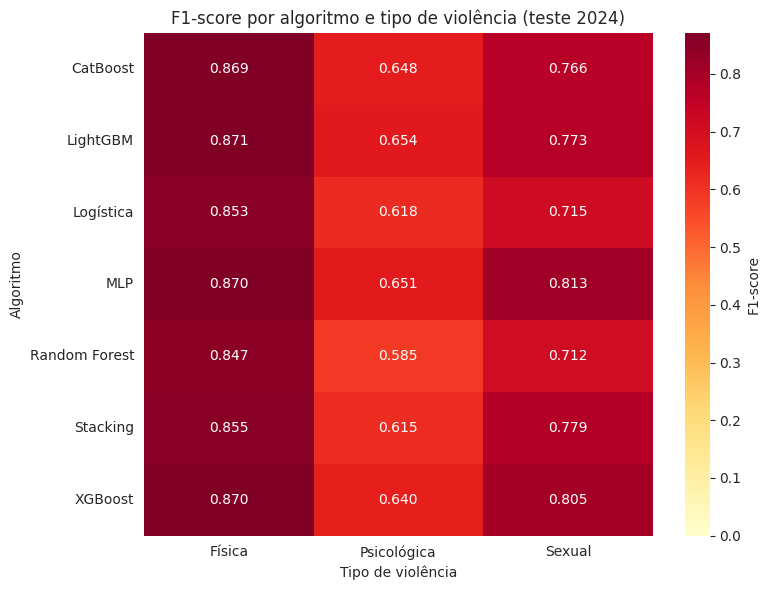

In [16]:
pivot_f1 = df_res.pivot(index='modelo', columns='alvo', values='f1')
pivot_f1.columns = ['Física', 'Psicológica', 'Sexual']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_f1, annot=True, fmt='.3f', cmap='YlOrRd',
            cbar_kws={'label': 'F1-score'}, ax=ax,
            vmin=0, vmax=pivot_f1.max().max())
ax.set_title('F1-score por algoritmo e tipo de violência (teste 2024)')
ax.set_xlabel('Tipo de violência')
ax.set_ylabel('Algoritmo')
plt.tight_layout()
plt.savefig(RESULTADOS / 'heatmap_f1.png', dpi=150, bbox_inches='tight')
plt.show()

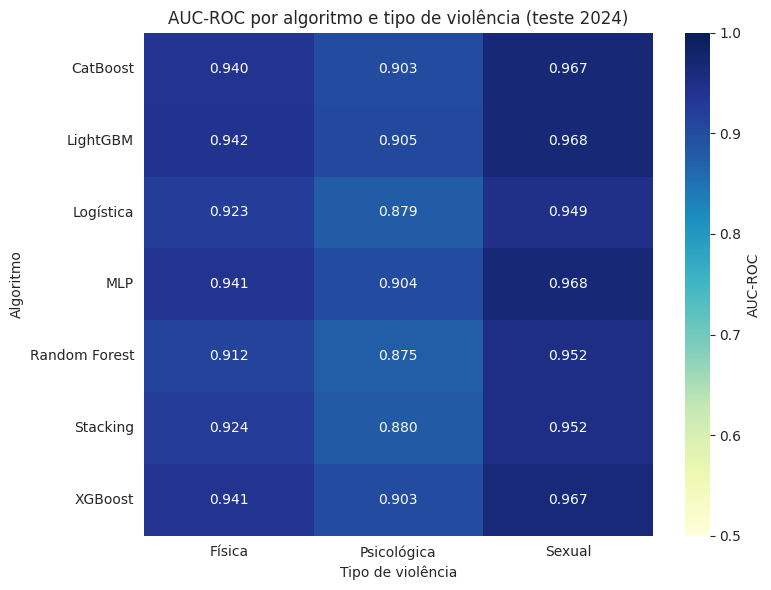

In [17]:
pivot_auc = df_res.pivot(index='modelo', columns='alvo', values='auc_roc')
pivot_auc.columns = ['Física', 'Psicológica', 'Sexual']

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(pivot_auc, annot=True, fmt='.3f', cmap='YlGnBu',
            cbar_kws={'label': 'AUC-ROC'}, ax=ax,
            vmin=0.5, vmax=1.0)
ax.set_title('AUC-ROC por algoritmo e tipo de violência (teste 2024)')
ax.set_xlabel('Tipo de violência')
ax.set_ylabel('Algoritmo')
plt.tight_layout()
plt.savefig(RESULTADOS / 'heatmap_auc.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Melhores modelos e matrizes de confusão

Melhor modelo por desfecho (F1):

   alvo   modelo     f1  auc_roc  auc_pr
y_fisic LightGBM 0.8711   0.9422  0.9469
y_psico LightGBM 0.6545   0.9049  0.7627
 y_sexu      MLP 0.8127   0.9678  0.8862


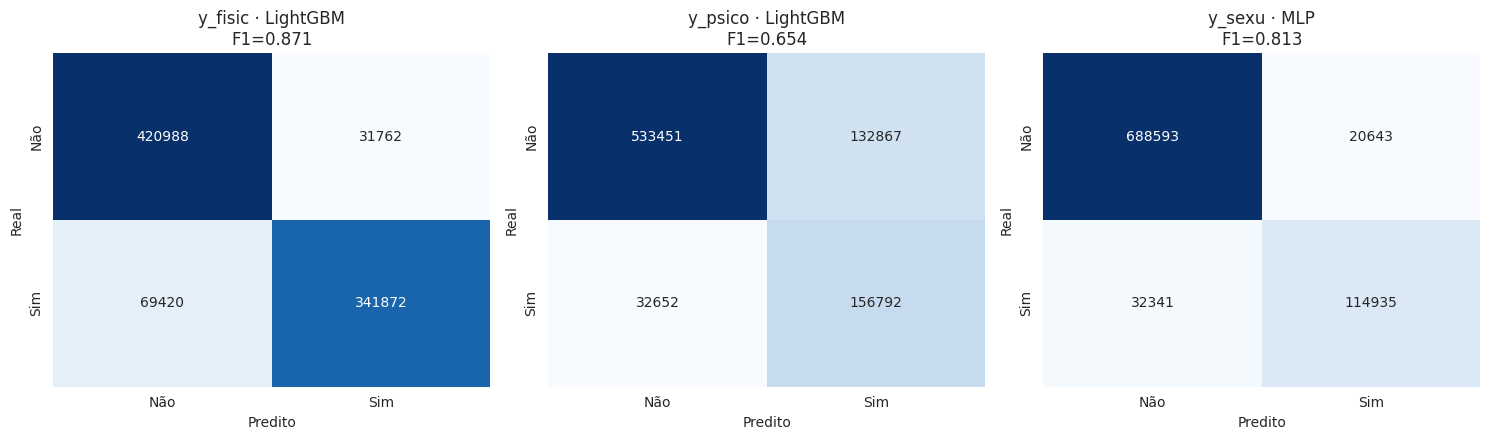

In [18]:
melhores = df_res.loc[df_res.groupby('alvo')['f1'].idxmax()]
print('Melhor modelo por desfecho (F1):\n')
print(melhores[['alvo', 'modelo', 'f1', 'auc_roc', 'auc_pr']].to_string(index=False))

# Matrizes de confusão dos melhores
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (_, row) in zip(axes, melhores.iterrows()):
    cm = [r['matriz_conf'] for r in resultados
          if r['modelo']==row['modelo'] and r['alvo']==row['alvo']][0]
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Não','Sim'], yticklabels=['Não','Sim'],
                cbar=False)
    ax.set_title(f'{row["alvo"]} · {row["modelo"]}\nF1={row["f1"]:.3f}')
    ax.set_xlabel('Predito')
    ax.set_ylabel('Real')
plt.tight_layout()
plt.savefig(RESULTADOS / 'matrizes_confusao.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Comparação visual — F1 por algoritmo (3 painéis)

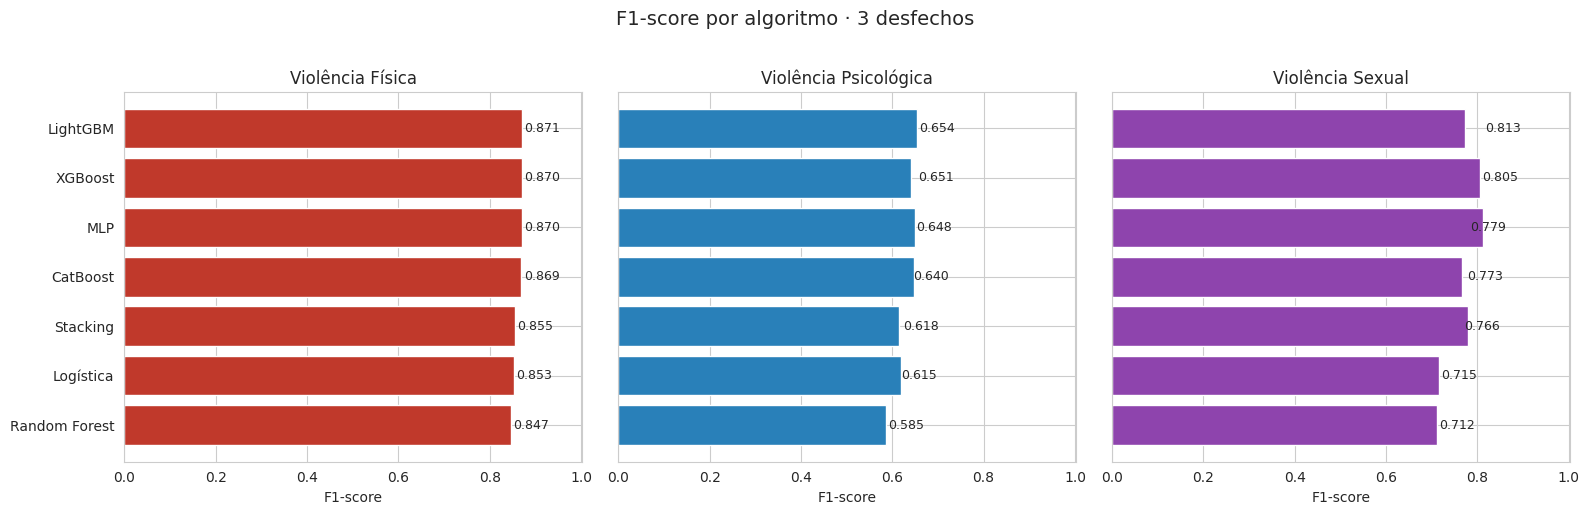

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
cores = {'y_fisic':'#c0392b', 'y_psico':'#2980b9', 'y_sexu':'#8e44ad'}
nomes = {'y_fisic':'Física', 'y_psico':'Psicológica', 'y_sexu':'Sexual'}

for ax, alvo in zip(axes, ALVOS):
    sub = df_res[df_res['alvo']==alvo].sort_values('f1', ascending=True)
    ax.barh(sub['modelo'], sub['f1'], color=cores[alvo])
    ax.set_title(f'Violência {nomes[alvo]}')
    ax.set_xlabel('F1-score')
    ax.set_xlim(0, max(df_res['f1']) * 1.15)
    for i, v in enumerate(sub['f1']):
        ax.text(v + 0.005, i, f'{v:.3f}', va='center', fontsize=9)

plt.suptitle('F1-score por algoritmo · 3 desfechos', y=1.02, fontsize=14)
plt.tight_layout()
plt.savefig(RESULTADOS / 'barras_f1.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Tempo de treinamento por modelo

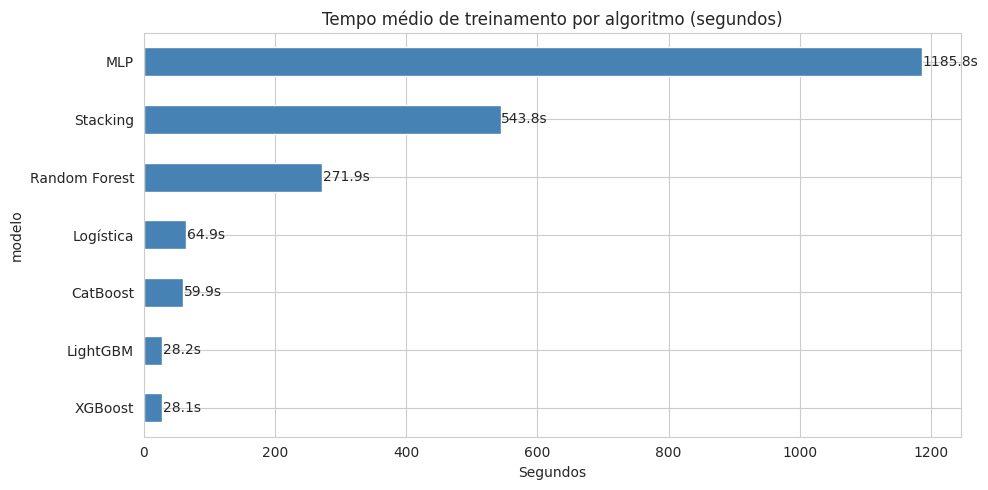

In [20]:
tempos = df_res.groupby('modelo')['tempo_treino'].mean().sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
tempos.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Tempo médio de treinamento por algoritmo (segundos)')
ax.set_xlabel('Segundos')
for i, v in enumerate(tempos):
    ax.text(v + 1, i, f'{v:.1f}s', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## 12. Síntese

**Pontos a observar nos resultados:**

1. **Qual algoritmo predomina** em cada desfecho? Existe um vencedor global ou ele varia por tipo?
2. **Gradient Boosting (XGBoost/LightGBM/HistGB)** confirma o estado da arte para dados tabulares?
3. **MLP** se beneficia da alta dimensionalidade pós-One-Hot ou sobreajusta?
4. **Stacking** consegue extrair ganho marginal sobre os componentes individuais?
5. Existe trade-off claro entre **qualidade e tempo** que recomende um algoritmo para a versão final?

**Próximas etapas:**
- Análise de importância de features (SHAP) nos melhores modelos
- Teste estatístico (Friedman + Nemenyi) para comparação formal entre algoritmos
- Refinamento de hiperparâmetros com GridSearchCV nos 2-3 melhores